In [1]:
import os


os.chdir(os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

## Setup
First of all, check the Python version. This sources have been coded with the following Python version:

In [2]:
!python --version

Python 3.11.13


Then, install the dependencies in the `requirement.txt` file. The main dependency is the python packege `bcause` (https://github.com/PGM-Lab/bcause).

In [ ]:
!pip install --upgrade pip setuptools wheel
!pip install -r ./requirements.txt
!pip install polytope~=0.2.5 --no-deps

## Model and data

In this repository, we provide functionality for preprocessing the model and data so they could work we our inference algorithm:

In [3]:
from ctfzeros.prepro import load_and_preprocess

In [4]:
filepath = "./models/simple_nparents1_nzr10_zdr00_0.uai"
datapath = "./models/simple_nparents1_nzr10_zdr00_0.csv"

model, data, _, _ = load_and_preprocess(filepath, datapath)
model

<StructuralCausalModel (Y:2,X1:2|Uy:4,Ux1:2), dag=[Uy][Y|Uy:X1][X1|Ux1][Ux1]>

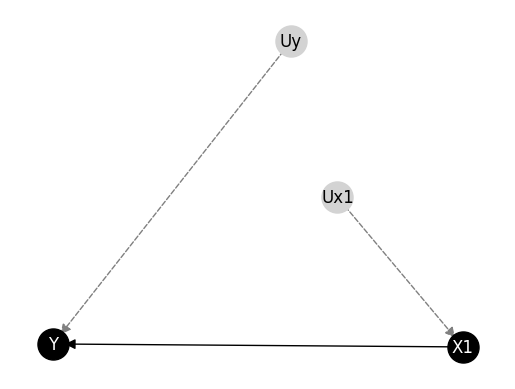

In [5]:
model.draw()

In [6]:
data

,X1,Y
0,0,1
1,0,1
2,0,0
3,0,1
4,1,1
...,...,...
995,0,0
996,1,0
997,0,0
998,0,1


## Counterfactual inference

First, load corresponding modules for using LPID and DC3ID:

In [7]:
from ctfzeros.imprecise_empirical import LPCC_imprecise_empirical, DCCC_imprecise_empirical


Set up the LPID inference engine with a perturbation $\epsilon=0.05$. Then calculate the probability of sufficiency $PS(X_1,Y)$:

In [8]:
infLPID = LPCC_imprecise_empirical(model, data, perturbation=0.05)
infLPID.prob_sufficiency("X1", "Y")

[7.724454227344187e-20, 0.4317658471578703]

Similarly, with the divide and conquer approach (DC3ID):

In [9]:
infDC3ID = DCCC_imprecise_empirical(model, data, perturbation=0.05)
infDC3ID.prob_sufficiency("X1", "Y")

[0.0, 0.4317658471578494]

Instead of the interval, we can obtain the list of individual queries:

In [10]:
infDC3ID.set_interval_result(False)
infDC3ID.prob_sufficiency("X1", "Y")

[0.3702430867734918,
 0.2277520565325892,
 0.4317658471578494,
 0.2655972876838508,
 0.0,
 0.0,
 0.0,
 0.0]

Finally, we can do the inference with a reduced number of solutions (`num_runs=5`) which can lead to an approximation:

In [12]:
infDC3ID = DCCC_imprecise_empirical(model, data, perturbation=0.05, num_runs=5)
infDC3ID.set_interval_result(False)
infDC3ID.prob_sufficiency("X1", "Y")

[0.22775205653259195,
 0.2655972876838502,
 0.3702430867734911,
 0.4317658471578494,
 0.0]